In [17]:
# ==========================================================
# COMPLETE EVALUATION PIPELINE (GOLD + PRED SEPARATE FILES)
# ==========================================================

import json
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
import seaborn as sns
from sklearn.metrics import adjusted_rand_score
import anndata as ad

# ==============================
# CONFIG
# ==============================

GOLD_PATH = '../experiments/gold/doi20_gold_gt.json'
RESULTS_ROOT = '../experiments/results/part1_4'
# ADATA_ROOT = "adata_folder"         # <- where dataset_id.h5ad lives
ARI_THRESHOLD = 0.9

FIELDS = ["batch", "donor", "disease", "sex", "species", "technology"]

# ==============================
# LOAD GOLD
# ==============================

def load_gold(gold_path):
    with open(gold_path) as f:
        gold = json.load(f)

    rows = []
    for item in gold["items"]:
        for field in FIELDS:
            rows.append({
                "doi": item["doi"],
                "dataset_id": item["dataset_id"],
                "adata_path": item["h5ad_path"],
                "field": field,
                "gt_column": item["columns_selection"].get(field),
                "gt_global": item["global_inference"].get(field),
            })

    return pd.DataFrame(rows)

# ==============================
# LOAD PREDICTIONS
# ==============================

def load_predictions(results_root):
    rows = []

    for pred_path in glob.glob(f"{results_root}/**/pred.json", recursive=True):
        # if 'qwen3_8b' in pred_path:
        #     continue

        try:
            with open(pred_path) as f:
                pred = json.load(f)

            for field in FIELDS:
                rows.append({
                    "model": pred["model"],
                    "doi": pred["doi"],
                    "dataset_id": pred["dataset_id"],
                    "field": field,
                    "pred_column": pred["report"]["columns_selection"].get(field),
                    "pred_global": (
                        pred["report"]["global_inference"]
                        .get(field, {})
                        .get("value")
                    ),
                })

        except Exception as e:
            print(e)
            print(pred_path)

    return pd.DataFrame(rows)

# ==============================
# MERGE
# ==============================

def build_eval_df(gold_df, pred_df):
    return pred_df.merge(
        gold_df,
        on=["doi", "dataset_id", "field"],
        how="left"
    )

# ==============================
# LOAD DATA
# ==============================

gold_df = load_gold(GOLD_PATH)
pred_df = load_predictions(RESULTS_ROOT)
df = build_eval_df(gold_df, pred_df)

df = df.replace({None: np.nan})

In [18]:
# ==============================
# ADATA CACHE
# ==============================

adata_cache = {}

def get_adata(path):
    path = "../" + path
    if path not in adata_cache:
        adata_cache[path] = ad.read_h5ad(path)
    return adata_cache[path]

def compute_ari(path, col1, col2):
    try:
        adata = get_adata(path)
        if col1 not in adata.obs.columns:
            return None
        if col2 not in adata.obs.columns:
            return None

        return adjusted_rand_score(
            adata.obs[col1].astype("category"),
            adata.obs[col2].astype("category"),
        )
    except Exception:
        return None

# ==============================
# COLUMN CLASSIFICATION
# ==============================

def classify_column(row):

    gt = row["gt_column"]
    pred = row["pred_column"]

    if pd.notna(gt):

        if pd.isna(pred):
            return "miss", None

        if isinstance(pred, str) and pred.startswith("hallucinated:"):
            return "harmful_hallucination", None

        if pred == gt:
            return "exact_match", 1.0

        ari = compute_ari(row["adata_path"], gt, pred)

        if ari is not None and ari >= ARI_THRESHOLD:
            return "semantic_match", ari

        return "wrong_existing", ari

    else:

        if pd.isna(pred):
            return "correct_null", None

        if isinstance(pred, str) and pred.startswith("hallucinated:"):
            return "benign_hallucination", None

        return "false_positive", None

cases = df.apply(classify_column, axis=1)
df["column_case"] = [c[0] for c in cases]
df["ari"] = [c[1] for c in cases]

# ==============================
# GLOBAL CLASSIFICATION
# ==============================

def classify_global(row):

    if pd.notna(row["gt_column"]):
        return "not_needed"

    if pd.isna(row["pred_global"]):
        return "miss"

    if row["pred_global"] == row["gt_global"]:
        return "correct"

    return "wrong"

df["global_case"] = df.apply(classify_global, axis=1)

# ==============================
# END-TO-END
# ==============================

def end_to_end(row):

    if pd.notna(row["gt_column"]):
        return row["column_case"] in ["exact_match", "semantic_match"]

    return row["global_case"] == "correct"

df["end_to_end"] = df.apply(end_to_end, axis=1)

# ==============================
# METRICS
# ==============================

column_metrics = (
    df.groupby("model")["column_case"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)

column_field_acc = (
    df[df["gt_column"].notna()]
    .groupby(["model", "field"])["column_case"]
    .apply(lambda x: ((x == "exact_match") | (x == "semantic_match")).mean())
    .unstack()
)

ari_heatmap = (
    df[df["ari"].notna()]
    .groupby(["model", "field"])["ari"]
    .mean()
    .unstack()
)

hallucination_heatmap = (
    df.groupby(["model", "field"])["column_case"]
    .apply(lambda x: (x == "harmful_hallucination").mean())
    .unstack()
)

# Global metrics
global_rows = []

for (model, field), sub in df[df["global_case"] != "not_needed"].groupby(["model", "field"]):

    tp = (sub["global_case"] == "correct").sum()
    fp = (sub["global_case"] == "wrong").sum()
    fn = (sub["global_case"] == "miss").sum()

    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    f1 = (2 * precision * recall / (precision + recall)
          if (precision + recall) else 0)

    global_rows.append({
        "model": model,
        "field": field,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    })

global_metrics = pd.DataFrame(global_rows)
global_precision_heatmap = global_metrics.pivot(index="model", columns="field", values="precision")
global_recall_heatmap = global_metrics.pivot(index="model", columns="field", values="recall")
global_f1_heatmap = global_metrics.pivot(index="model", columns="field", values="f1")

end_to_end_heatmap = (
    df.groupby(["model", "field"])["end_to_end"]
    .mean()
    .unstack()
)

In [19]:
df

,model,doi,dataset_id,field,pred_column,pred_global,adata_path,gt_column,gt_global,column_case,ari,global_case,end_to_end
0,gemma3:latest,10.1038/s41586-020-2157-4,2adb1f8a-a6b1-4909-8ee8-484814e2d4bf,batch,batch,NaN,experiments/data/doi20/10.1038_s41586-020-2157...,batch,NaN,exact_match,1.0,not_needed,True
1,gemma3:latest,10.1038/s41586-020-2157-4,2adb1f8a-a6b1-4909-8ee8-484814e2d4bf,donor,donor_id,NaN,experiments/data/doi20/10.1038_s41586-020-2157...,donor_id,NaN,exact_match,1.0,not_needed,True
2,gemma3:latest,10.1038/s41586-020-2157-4,2adb1f8a-a6b1-4909-8ee8-484814e2d4bf,disease,disease,NaN,experiments/data/doi20/10.1038_s41586-020-2157...,disease,NaN,exact_match,1.0,not_needed,True
3,gemma3:latest,10.1038/s41586-020-2157-4,2adb1f8a-a6b1-4909-8ee8-484814e2d4bf,sex,sex_ontology_term_id,NaN,experiments/data/doi20/10.1038_s41586-020-2157...,sex,NaN,wrong_existing,NaN,not_needed,False
4,gemma3:latest,10.1038/s41586-020-2157-4,2adb1f8a-a6b1-4909-8ee8-484814e2d4bf,species,sex,Homo sapiens,experiments/data/doi20/10.1038_s41586-020-2157...,NaN,Homo sapiens,false_positive,NaN,correct,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,mistral-nemo:12b,10.1038/s41586-020-2922-4,8c42cfd0-0b0a-46d5-910c-fc833d83c45e,donor,donor_id,Homo sapiens,experiments/data/doi20/10.1038_s41586-020-2922...,donor_id,NaN,exact_match,1.0,not_needed,True
92,mistral-nemo:12b,10.1038/s41586-020-2922-4,8c42cfd0-0b0a-46d5-910c-fc833d83c45e,disease,NaN,NaN,experiments/data/doi20/10.1038_s41586-020-2922...,disease,NaN,miss,NaN,not_needed,False
93,mistral-nemo:12b,10.1038/s41586-020-2922-4,8c42cfd0-0b0a-46d5-910c-fc833d83c45e,sex,sex,NaN,experiments/data/doi20/10.1038_s41586-020-2922...,sex,NaN,exact_match,1.0,not_needed,True
94,mistral-nemo:12b,10.1038/s41586-020-2922-4,8c42cfd0-0b0a-46d5-910c-fc833d83c45e,species,NaN,Homo sapiens,experiments/data/doi20/10.1038_s41586-020-2922...,NaN,Homo sapiens,correct_null,NaN,correct,True


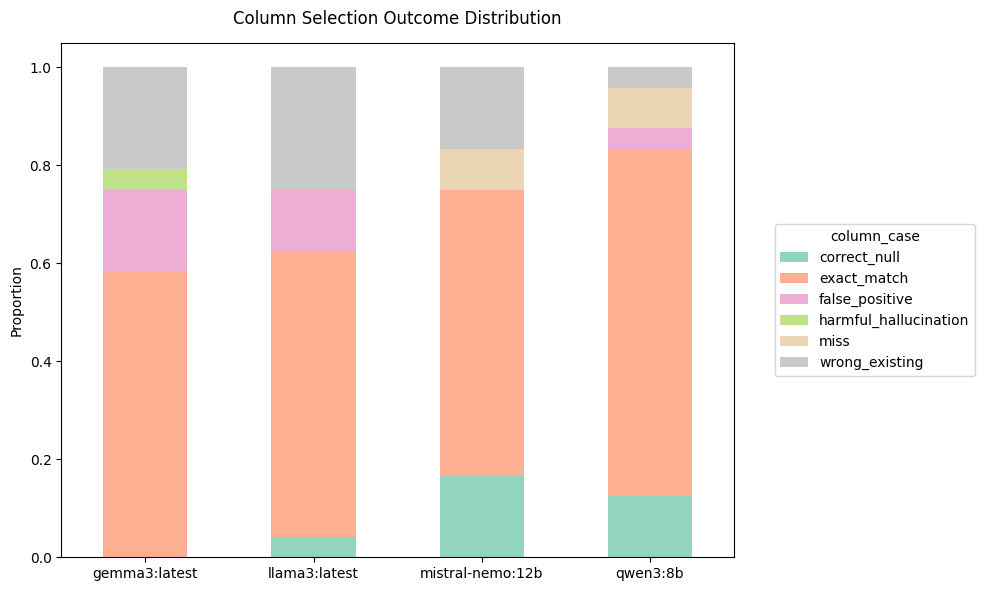

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# Example: convert seaborn palette to ListedColormap
palette = sns.color_palette("Set2", 8)
cmap = ListedColormap(palette) 

# Plot stacked bar
ax = column_metrics.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    colormap=cmap,
    alpha=0.7
)

# Move legend outside
ax.legend(
    title="column_case",       # optional title
    bbox_to_anchor=(1.05, 0.5),  # x=1.05 → just outside right, y=1 → top
    loc="center left"           # anchor point of legend box
)

plt.xlabel("")
plt.xticks(rotation=0, fontsize=10)
# plt.yticks(fontsize=12, fontweight='bold', fontfamily='serif')
plt.ylabel("Proportion", fontsize=10)

plt.title(
    f"Column Selection Outcome Distribution", 
    fontsize=12,
    y=1.02
)

plt.tight_layout()  # adjust layout so nothing overlaps
plt.savefig("/home/user/Downloads/columns_barplot.png", dpi=300)
plt.show()


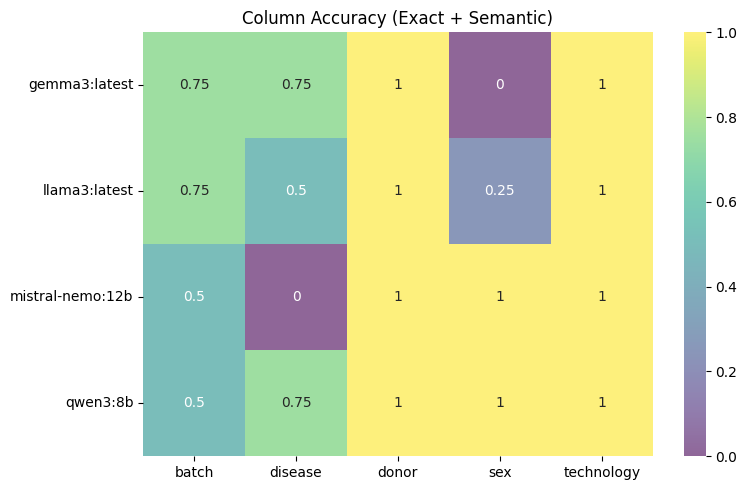

In [29]:
# ==============================
# PLOTS
# ==============================
palette = sns.color_palette("Set2", 8)
cmap = ListedColormap(palette) 

for title, data in [
    ("Column Accuracy (Exact + Semantic)", column_field_acc),
    # ("Mean ARI per Field", ari_heatmap),
    # ("Harmful Hallucination Rate", hallucination_heatmap),
    # ("Global Precision per Field", global_precision_heatmap),
    # ("Global Recall per Field", global_recall_heatmap),
    # ("Global F1 per Field", global_f1_heatmap),
    # ("End-to-End Accuracy per Field", end_to_end_heatmap),
]:
    plt.figure(figsize=(8,5))
    sns.heatmap(data, annot=True, cmap="viridis", alpha=0.6)
    plt.title(title, fontsize=12)
    # plt.ylabel("Models", fontsize=12, fontweight='bold', fontfamily='serif')
    plt.ylabel("")
    plt.yticks(rotation=0, fontsize=10)

    # plt.xlabel("Fields", fontsize=12, fontweight='bold', fontfamily='serif')
    plt.xlabel("")
    plt.xticks(fontsize=10)


    plt.tight_layout()
    plt.savefig("/home/user/Downloads/columns_heatmap_acc.png", dpi=300)
    plt.show()


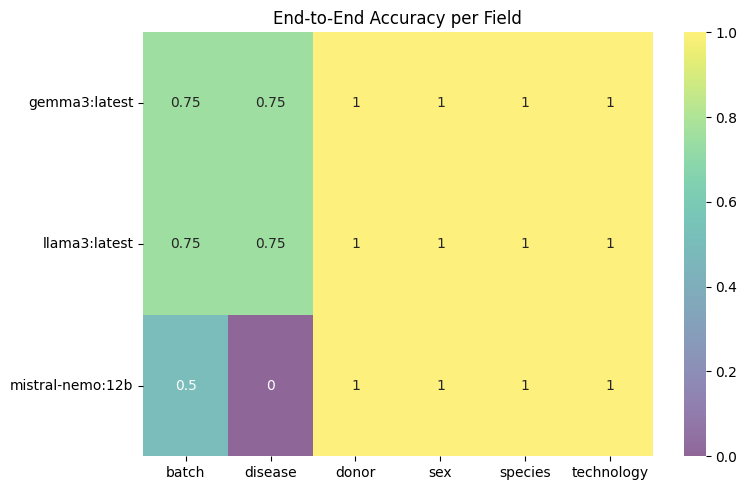

In [10]:
# ==============================
# PLOTS
# ==============================
palette = sns.color_palette("Set2", 5)
cmap = ListedColormap(palette) 

for title, data in [
    # ("Column Accuracy (Exact + Semantic)", column_field_acc),
    # ("Mean ARI per Field", ari_heatmap),
    # ("Harmful Hallucination Rate", hallucination_heatmap),
    # ("Global Precision per Field", global_precision_heatmap),
    # ("Global Recall per Field", global_recall_heatmap),
    # ("Global F1 per Field", global_f1_heatmap),
    ("End-to-End Accuracy per Field", end_to_end_heatmap),
]:
    plt.figure(figsize=(8,5))
    sns.heatmap(data, annot=True, cmap='viridis', alpha=0.6)
    plt.title(title, fontsize=12)
    # plt.ylabel("Models", fontsize=12, fontweight='bold', fontfamily='serif')
    plt.ylabel("")
    plt.yticks(rotation=0, fontsize=10)

    # plt.xlabel("Fields", fontsize=12, fontweight='bold', fontfamily='serif')
    plt.xlabel("")
    plt.xticks(fontsize=10)


    plt.tight_layout()
    plt.show()


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

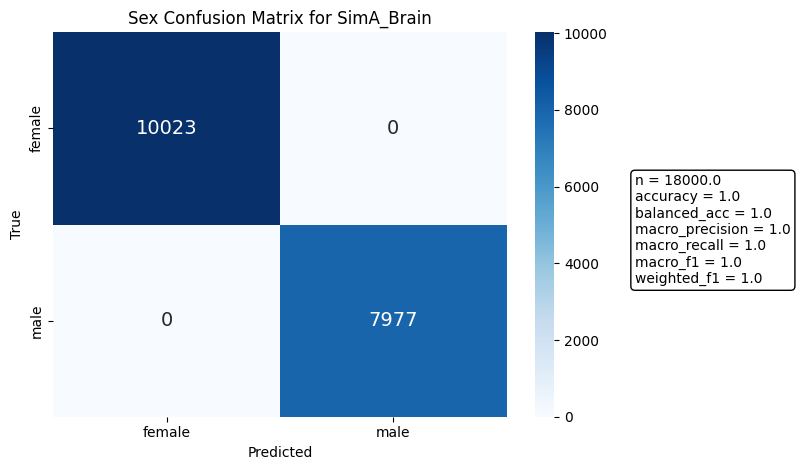

In [2]:
df_A = pd.DataFrame(
    [[10023, 0],
     [0, 7977]],
    index=["female", "male"],
    columns=["female", "male"]
)

plt.figure()
sns.heatmap(df_A, annot=True, fmt="d", cmap="Blues", annot_kws={"size": 14})
plt.title("Sex Confusion Matrix for SimA_Brain", fontsize=12)
plt.ylabel("True")
plt.xlabel("Predicted")

n=18000
accuracy=1
balanced_acc=1
macro_precision=1
macro_recall=1
macro_f1=1
weighted_f1=1

# Add metrics text
metrics_text = (
    f"n = {n:.1f}\n"
    f"accuracy = {accuracy:.1f}\n"
    f"balanced_acc = {balanced_acc:.1f}\n"
    f"macro_precision = {macro_precision:.1f}\n"
    f"macro_recall = {macro_recall:.1f}\n"
    f"macro_f1 = {macro_f1:.1f}\n"
    f"weighted_f1 = {weighted_f1:.1f}"
)

plt.figtext(
    1, 0.4, metrics_text,
    fontsize=10,
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round')
)

plt.tight_layout()
plt.savefig("/home/user/Documents/h5adify_sex/sex_analysis_results/part3_sex_simA.png", dpi=400, bbox_inches="tight")
plt.show()

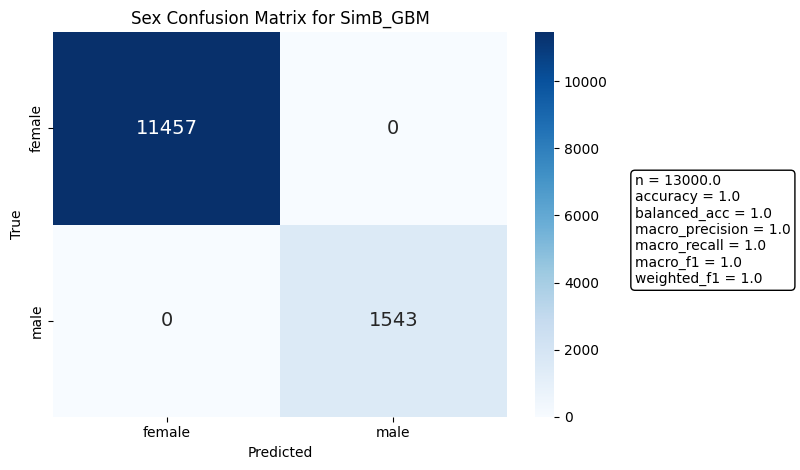

In [3]:
df_A = pd.DataFrame(
    [[11457, 0],
     [0, 1543]],
    index=["female", "male"],
    columns=["female", "male"]
)

plt.figure()
sns.heatmap(df_A, annot=True, fmt="d", cmap="Blues", annot_kws={"size": 14})
plt.title("Sex Confusion Matrix for SimB_GBM", fontsize=12)
plt.ylabel("True")
plt.xlabel("Predicted")

n=13000
accuracy=1
balanced_acc=1
macro_precision=1
macro_recall=1
macro_f1=1
weighted_f1=1

# Add metrics text
metrics_text = (
    f"n = {n:.1f}\n"
    f"accuracy = {accuracy:.1f}\n"
    f"balanced_acc = {balanced_acc:.1f}\n"
    f"macro_precision = {macro_precision:.1f}\n"
    f"macro_recall = {macro_recall:.1f}\n"
    f"macro_f1 = {macro_f1:.1f}\n"
    f"weighted_f1 = {weighted_f1:.1f}"
)

plt.figtext(
    1, 0.4, metrics_text,
    fontsize=10,
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round')
)

plt.tight_layout()
plt.savefig("/home/user/Documents/h5adify_sex/sex_analysis_results/part3_sex_simB.png", dpi=400, bbox_inches="tight")
plt.show()

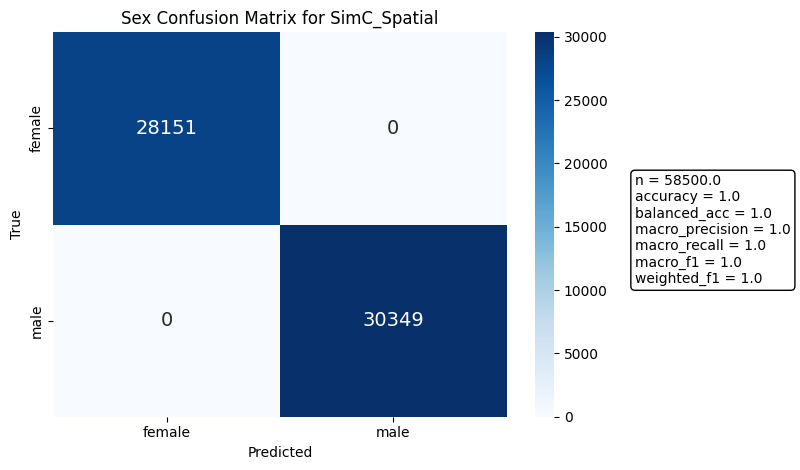

In [4]:
df_A = pd.DataFrame(
    [[28151, 0],
     [0, 30349]],
    index=["female", "male"],
    columns=["female", "male"]
)

plt.figure()
sns.heatmap(df_A, annot=True, fmt="d", cmap="Blues", annot_kws={"size": 14})
plt.title("Sex Confusion Matrix for SimC_Spatial", fontsize=12)
plt.ylabel("True")
plt.xlabel("Predicted")

n=58500
accuracy=1
balanced_acc=1
macro_precision=1
macro_recall=1
macro_f1=1
weighted_f1=1

# Add metrics text
metrics_text = (
    f"n = {n:.1f}\n"
    f"accuracy = {accuracy:.1f}\n"
    f"balanced_acc = {balanced_acc:.1f}\n"
    f"macro_precision = {macro_precision:.1f}\n"
    f"macro_recall = {macro_recall:.1f}\n"
    f"macro_f1 = {macro_f1:.1f}\n"
    f"weighted_f1 = {weighted_f1:.1f}"
)

plt.figtext(
    1, 0.4, metrics_text,
    fontsize=10,
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round')
)

plt.tight_layout()
plt.savefig("/home/user/Documents/h5adify_sex/sex_analysis_results/part3_sex_simC.png", dpi=400, bbox_inches="tight")
plt.show()